# 🌊 Sentiment Analysis (VADER) — Water Scarcity Simulation

This notebook analyzes the **sentiment** of the text comments produced by a
water-allocation simulation during a heatwave.

## Where the comments live

Of the 4 CSV files, only two contain free text (comments):

| File | Text field | What it is |
|------|-----------|------------|
| `decisions_*.csv` | **`text`** | statements from stakeholders (hospital, households, industry, EPA, …) |
| `decisions_*.csv` | `reasoning` | internal justification of a move |
| `outcomes_*.csv`  | **`ruling_text`** | verdicts issued by the Water Authority |
| `weights_*.csv`   | `reason` | short technical notes (`no move today`) — not analyzed |
| `zones_*.csv`     | — | numbers only, no text |

**VADER metric** — `compound`, from **−1 (very negative)** to **+1 (very positive)**.
Labels: `compound ≥ 0.05` → positive, `≤ −0.05` → negative, otherwise neutral.


In [1]:
# --- Install VADER if missing ---
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "vaderSentiment"])
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import glob, os, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Shared sentiment palette
C_POS, C_NEU, C_NEG = "#2a9d8f", "#adb5bd", "#e76f51"
SENT_ORDER  = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": C_NEG, "neutral": C_NEU, "positive": C_POS}

analyzer = SentimentIntensityAnalyzer()
print("VADER ready")

VADER ready


In [2]:
# --- Load the most recent CSVs (timestamped names are picked automatically) ---
# The notebook may live in a subfolder (e.g. NLP/), so search here AND one level up.
def latest(prefix):
    files = sorted(glob.glob(f"{prefix}_*.csv") + glob.glob(f"../{prefix}_*.csv"))
    if not files:
        raise FileNotFoundError(f"{prefix}_*.csv not found in . or ..")
    return files[-1]

decisions = pd.read_csv(latest("decisions"))
outcomes  = pd.read_csv(latest("outcomes"))

print("decisions:", decisions.shape, "| days", decisions['day'].min(), "-", decisions['day'].max())
print("outcomes: ", outcomes.shape)
print("conditions:", list(decisions['condition'].unique()))
print("stakeholders:", list(decisions['stakeholder_id'].unique()))
decisions.head(2)

decisions: (3195, 13) | days 1 - 6
outcomes:  (324, 25)
conditions: ['no_cascade', 'cascade', 'deeper_cascade']
stakeholders: ['hospital', 'households', 'agriculture', 'industry', 'energy_utility', 'epa', 'water_authority']


,day,stakeholder_id,name,event_type,round,move_type,units,trade_target,text,run_id,condition,seed,reasoning
0,1,hospital,Hospital / Healthcare Services,request,0,request,150.0,NaN,Our hospitals and clinics cannot safely reduce...,no_cascade_seed0,no_cascade,0,NaN
1,1,households,Households,request,0,request,400.0,NaN,Households need the full baseline today to pre...,no_cascade_seed0,no_cascade,0,NaN


In [3]:
# --- VADER scoring helpers ---
def label(c):
    if c >= 0.05:  return "positive"
    if c <= -0.05: return "negative"
    return "neutral"

def score(series):
    comp = series.astype(str).apply(lambda t: analyzer.polarity_scores(t)["compound"])
    return comp, comp.apply(label)

# Stakeholder statements
decisions["compound"], decisions["sentiment"] = score(decisions["text"])

# Water Authority verdicts
rulings = outcomes.dropna(subset=["ruling_text"]).copy()
rulings["compound"], rulings["sentiment"] = score(rulings["ruling_text"])

print("Mean compound of stakeholder statements: %.3f" % decisions["compound"].mean())
print("Mean compound of authority verdicts:     %.3f" % rulings["compound"].mean())
decisions[["day","stakeholder_id","condition","compound","sentiment","text"]].head(3)

Mean compound of stakeholder statements: -0.146
Mean compound of authority verdicts:     0.025


,day,stakeholder_id,condition,compound,sentiment,text
0,1,hospital,no_cascade,-0.1916,negative,Our hospitals and clinics cannot safely reduce...
1,1,households,no_cascade,-0.1779,negative,Households need the full baseline today to pre...
2,1,agriculture,no_cascade,0.4907,positive,"Agriculture can absorb a single difficult day,..."


## 1. Overall sentiment distribution
Were comments mostly positive, negative or neutral?

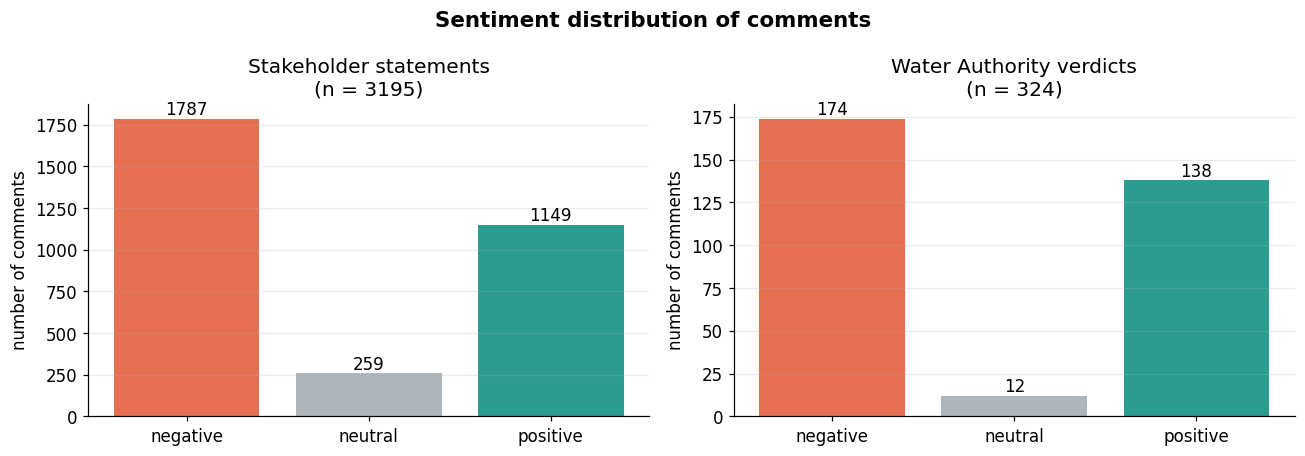

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, df, title in [
    (axes[0], decisions, "Stakeholder statements"),
    (axes[1], rulings,   "Water Authority verdicts"),
]:
    counts = df["sentiment"].value_counts().reindex(SENT_ORDER).fillna(0)
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[s] for s in counts.index])
    ax.set_title(f"{title}\n(n = {int(counts.sum())})")
    ax.set_ylabel("number of comments")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                f"{int(b.get_height())}", ha="center", va="bottom")
    ax.grid(axis="x")

fig.suptitle("Sentiment distribution of comments", fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

## 2. How sentiment changed over time
Mean `compound` per simulation day — is tension rising or easing?

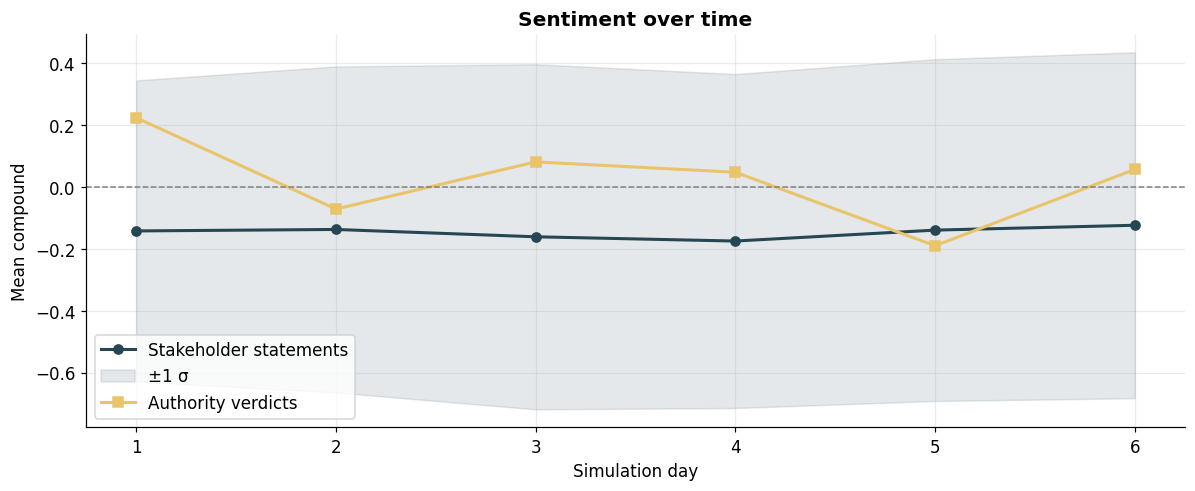

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.6))

by_day = decisions.groupby("day")["compound"].agg(["mean","std","count"])
ax.plot(by_day.index, by_day["mean"], "-o", color="#264653", lw=2, label="Stakeholder statements")
ax.fill_between(by_day.index,
                by_day["mean"]-by_day["std"], by_day["mean"]+by_day["std"],
                color="#264653", alpha=0.12, label="±1 σ")

r_day = rulings.groupby("day")["compound"].mean()
ax.plot(r_day.index, r_day.values, "-s", color="#e9c46a", lw=2, label="Authority verdicts")

ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Simulation day"); ax.set_ylabel("Mean compound")
ax.set_title("Sentiment over time", weight="bold")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Sentiment by stakeholder
Who sounds positive and who sounds negative?

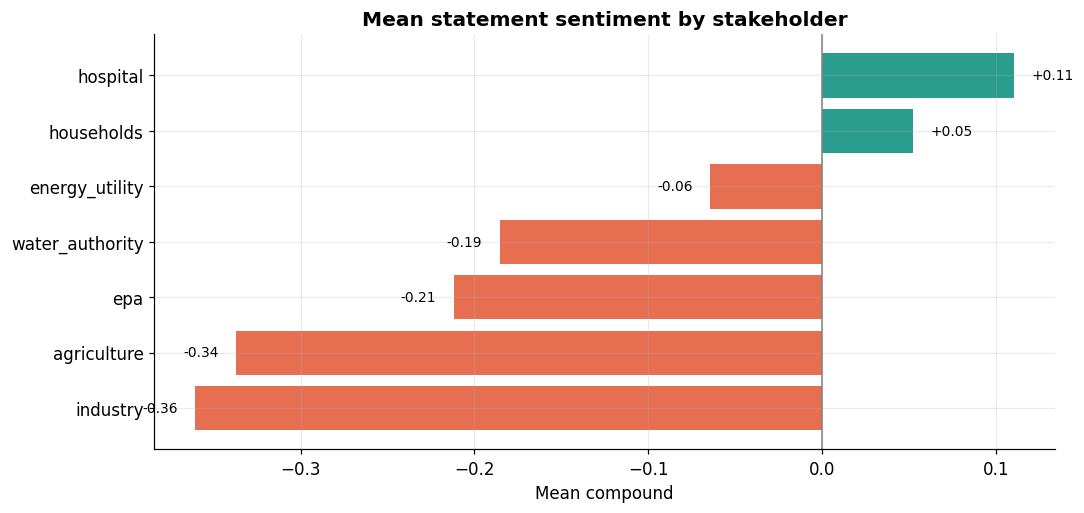

In [6]:
order = decisions.groupby("stakeholder_id")["compound"].mean().sort_values()
colors = [C_NEG if v < -0.05 else C_POS if v > 0.05 else C_NEU for v in order.values]

fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.barh(order.index, order.values, color=colors)
ax.axvline(0, color="gray", lw=1)
for b, v in zip(bars, order.values):
    ax.text(v + (0.01 if v>=0 else -0.01), b.get_y()+b.get_height()/2,
            f"{v:+.2f}", va="center", ha="left" if v>=0 else "right", fontsize=9)
ax.set_xlabel("Mean compound")
ax.set_title("Mean statement sentiment by stakeholder", weight="bold")
plt.tight_layout(); plt.show()

## 4. Sentiment by scenario condition
Three conditions: `no_cascade`, `cascade`, `deeper_cascade` — does cascading make things more negative?

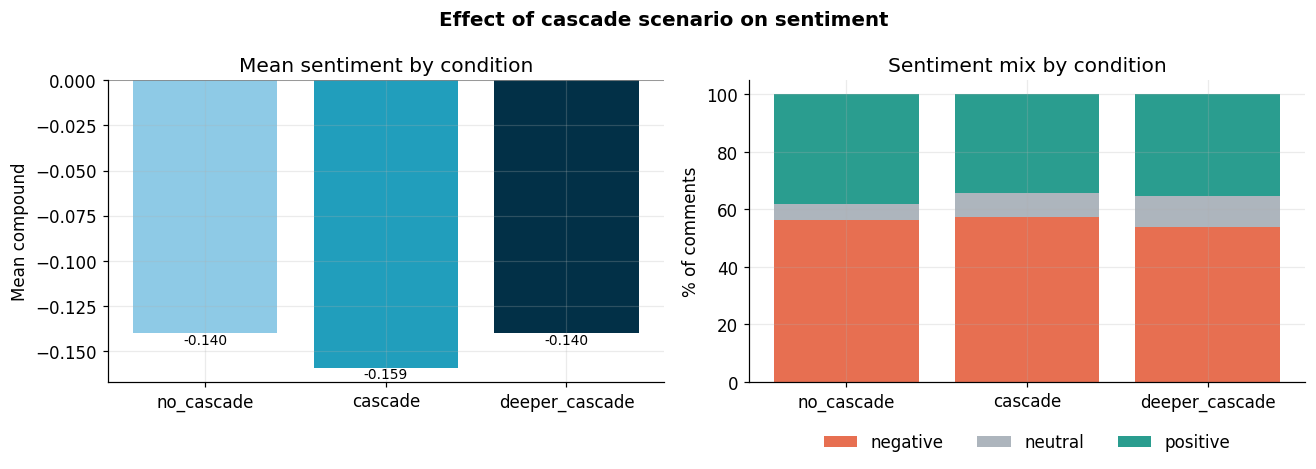

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# mean compound per condition
cond = decisions.groupby("condition")["compound"].mean().reindex(
    ["no_cascade","cascade","deeper_cascade"]).dropna()
axes[0].bar(cond.index, cond.values, color=["#8ecae6","#219ebc","#023047"])
axes[0].axhline(0, color="gray", lw=1)
for i,v in enumerate(cond.values):
    axes[0].text(i, v, f"{v:+.3f}", ha="center", va="bottom" if v>=0 else "top", fontsize=9)
axes[0].set_ylabel("Mean compound"); axes[0].set_title("Mean sentiment by condition")

# sentiment share per condition (stacked %)
share = (decisions.groupby(["condition","sentiment"]).size()
         .unstack(fill_value=0).reindex(columns=SENT_ORDER, fill_value=0))
share = share.reindex(["no_cascade","cascade","deeper_cascade"]).dropna()
share_pct = share.div(share.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(share_pct))
for s in SENT_ORDER:
    axes[1].bar(share_pct.index, share_pct[s], bottom=bottom,
                color=SENT_COLORS[s], label=s)
    bottom += share_pct[s].values
axes[1].set_ylabel("% of comments"); axes[1].set_title("Sentiment mix by condition")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5,-0.12), ncol=3, frameon=False)

fig.suptitle("Effect of cascade scenario on sentiment", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

## 5. Heatmap: stakeholder × day
Where and when negativity concentrates.

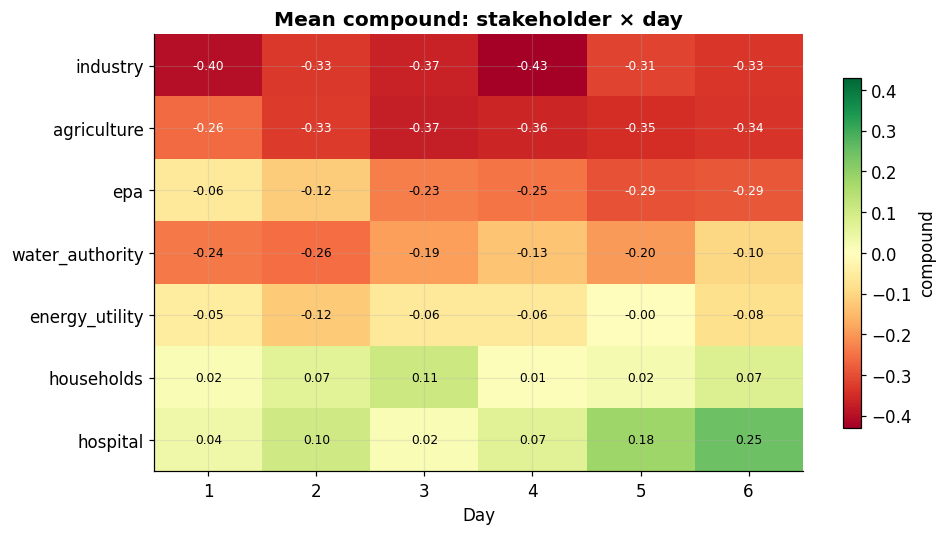

In [8]:
pivot = decisions.pivot_table(index="stakeholder_id", columns="day",
                              values="compound", aggfunc="mean")
pivot = pivot.reindex(order.index)  # same order as section 3

fig, ax = plt.subplots(figsize=(9, 5))
vmax = np.nanmax(np.abs(pivot.values))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels(pivot.index)
ax.set_xlabel("Day"); ax.set_title("Mean compound: stakeholder × day", weight="bold")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="black" if abs(v)<vmax*0.6 else "white", fontsize=8)
fig.colorbar(im, ax=ax, label="compound", shrink=0.8)
plt.tight_layout(); plt.show()

## 6. Score distribution (histogram)
How polarized the stakeholder statements are.

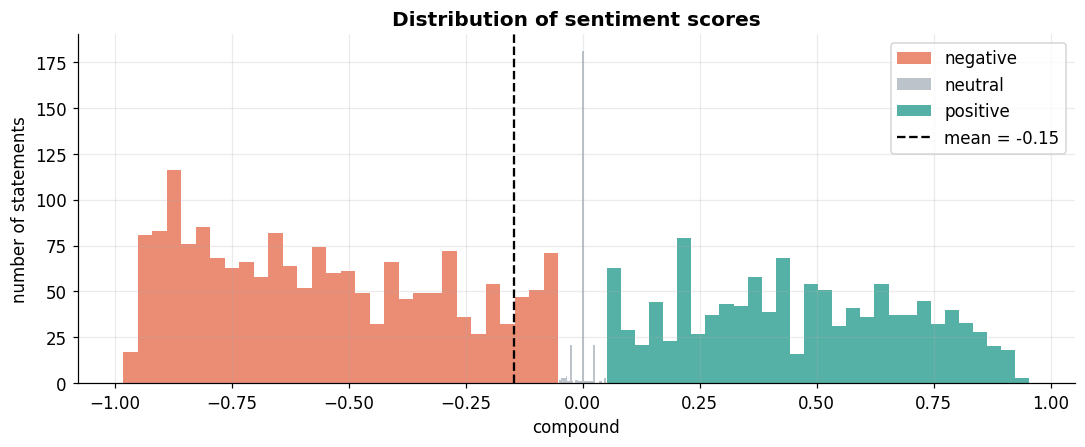

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
for s in SENT_ORDER:
    sub = decisions.loc[decisions["sentiment"]==s, "compound"]
    ax.hist(sub, bins=30, color=SENT_COLORS[s], alpha=0.8, label=s)
ax.axvline(decisions["compound"].mean(), color="black", ls="--", lw=1.5,
           label=f"mean = {decisions['compound'].mean():.2f}")
ax.set_xlabel("compound"); ax.set_ylabel("number of statements")
ax.set_title("Distribution of sentiment scores", weight="bold")
ax.legend(); plt.tight_layout(); plt.show()

## 7. 🗺️ Global sentiment map — with real text examples

Every dot is **one stakeholder statement**, positioned by **day** (x, with jitter) and
**compound score** (y), colored by sentiment. A few representative statements are pinned
with **callout boxes showing the actual text**, so you can see *what kind of language*
produces each sentiment level.

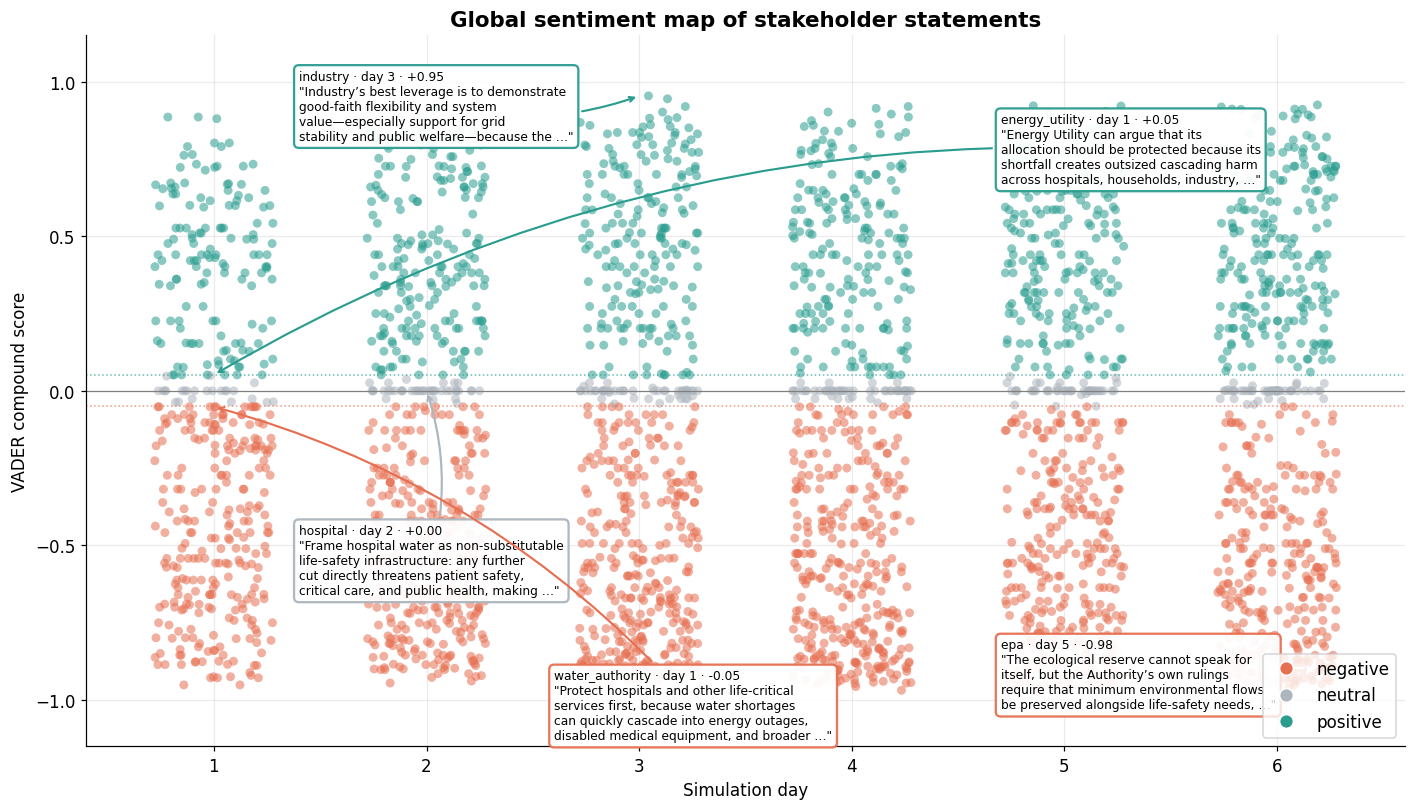

In [10]:
rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(13, 7.5))

# all statements as a scattered cloud
x = decisions["day"] + rng.uniform(-0.28, 0.28, len(decisions))
ax.scatter(x, decisions["compound"],
           c=decisions["sentiment"].map(SENT_COLORS),
           s=34, alpha=0.55, edgecolors="none", zorder=2)

ax.axhline(0.05, color=C_POS, lw=1, ls=":", alpha=0.7)
ax.axhline(-0.05, color=C_NEG, lw=1, ls=":", alpha=0.7)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Simulation day"); ax.set_ylabel("VADER compound score")
ax.set_xlim(decisions["day"].min()-0.6, decisions["day"].max()+0.6)
ax.set_ylim(-1.15, 1.15)
ax.set_title("Global sentiment map of stakeholder statements", weight="bold", fontsize=14)

# legend
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor=SENT_COLORS[s],
                          markersize=9, label=s) for s in SENT_ORDER],
          loc="lower right", frameon=True)

# --- pick example statements to annotate ---
d = decisions.reset_index(drop=True)
examples = pd.concat([
    d.nlargest(1, "compound"),    # most positive
    d.nsmallest(1, "compound"),   # most negative
    d.iloc[(d["compound"].abs()).argsort()[:1]],   # most neutral (near 0)
    d[d["sentiment"]=="positive"].nsmallest(1, "compound"),  # mild positive
    d[d["sentiment"]=="negative"].nlargest(1, "compound"),   # mild negative
]).drop_duplicates(subset=["text"])

def wrap(t, w=42, lines=4):
    t = " ".join(str(t).split())
    out = textwrap.wrap(t, w)[:lines]
    if out and len(" ".join(out)) < len(t):
        out[-1] += " …"
    return "\n".join(out)

# fixed callout anchor positions (axes-fraction-ish, in data coords) to avoid overlap
anchors = [(1.4, 0.92), (4.7, -0.92), (1.4, -0.55), (4.7, 0.78), (2.6, -1.02)]
for (_, r), (ax_x, ax_y) in zip(examples.iterrows(), anchors):
    xi = r["day"]
    col = SENT_COLORS[r["sentiment"]]
    txt = f"{r['stakeholder_id']} · day {r['day']} · {r['compound']:+.2f}\n\"{wrap(r['text'])}\""
    ax.annotate(txt, xy=(xi, r["compound"]), xytext=(ax_x, ax_y),
                fontsize=8, ha="left", va="center", zorder=5,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=col, lw=1.5, alpha=0.95),
                arrowprops=dict(arrowstyle="->", color=col, lw=1.4,
                                connectionstyle="arc3,rad=0.15"))

plt.tight_layout(); plt.show()

## 8. Example statements (most positive / most negative)

In [11]:
def preview(t, n=170):
    t = " ".join(str(t).split())
    return t[:n] + ("…" if len(t) > n else "")

print("POSITIVE — top 3:\n")
for _, r in decisions.nlargest(3, "compound").iterrows():
    print(f"  [{r['compound']:+.2f}] day {r['day']}, {r['stakeholder_id']} ({r['condition']})")
    print(f"     {preview(r['text'])}\n")

print("NEGATIVE — top 3:\n")
for _, r in decisions.nsmallest(3, "compound").iterrows():
    print(f"  [{r['compound']:+.2f}] day {r['day']}, {r['stakeholder_id']} ({r['condition']})")
    print(f"     {preview(r['text'])}\n")

POSITIVE — top 3:

  [+0.95] day 3, industry (no_cascade)
     Industry’s best leverage is to demonstrate good-faith flexibility and system value—especially support for grid stability and public welfare—because the Authority has rewa…

  [+0.94] day 3, households (deeper_cascade)
     Households can absorb a modest sacrifice, but not visible hardship in 40°C heat; we propose a fair rebalancing that protects drinking water, hygiene, and basic cooling wh…

  [+0.93] day 6, households (cascade)
     Households can maintain our minimum today, but visible hardship at the household level will quickly become politically and socially destabilizing under 36°C heat. We are …

NEGATIVE — top 3:

  [-0.98] day 5, epa (no_cascade)
     The ecological reserve cannot speak for itself, but the Authority’s own rulings require that minimum environmental flows be preserved alongside life-safety needs, and Day…

  [-0.97] day 5, epa (deeper_cascade)
     The ecological reserve cannot be treated as discret

## Takeaways

- **Sentiment is computed by VADER** on `text` (stakeholder statements) and `ruling_text`
  (Water Authority verdicts). The `reason`/`zones` fields carry no analyzable text.
- **Over time** (§2) you can see how the mood shifts across the heatwave.
- **By stakeholder** (§3) industry and agriculture tend to be the most negative, while the
  hospital and households sound more neutral / positive.
- **Cascade conditions** (§4) let you compare whether escalation amplifies negativity.
- **The heatmap** (§5) localizes the pain points by day and sector.
- **The global map** (§7) shows the full sentiment landscape with real example text pinned on it.

> To analyze a different field (e.g. `reasoning`), just call
> `score(decisions["reasoning"].fillna(""))` and reuse the same plots.
